# Libraries

In [1]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
        roc_curve, 
        RocCurveDisplay, 
        confusion_matrix, 
        accuracy_score,
        recall_score,
        precision_score,
        f1_score,
        roc_auc_score,
        precision_recall_curve,
    )

import xgboost as xgb
import shap

# set warnings
import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)    
# setting the precision of floating numbers to 4 decimal points
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Functions

In [2]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold value
    """

    # predicting using the independent variables
    pred_temp = model.predict_proba(predictors)[:,1] > threshold
    pred = np.round(pred_temp)
    
    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [3]:
def confusion_matrix_sklearn(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold value
    """
    y_pred_temp = model.predict_proba(predictors)[:,1] > threshold
    y_pred = np.round(y_pred_temp)
    
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Load data

In [4]:
X_train = joblib.load('X_train.pkl')
X_val = joblib.load('X_val.pkl')
y_train = joblib.load('y_train.pkl')
y_val = joblib.load('y_val.pkl')

In [5]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184502 entries, 148091 to 4824
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   name_contract_type           184502 non-null  object 
 1   code_gender                  184502 non-null  object 
 2   flag_own_car                 184502 non-null  bool   
 3   flag_own_realty              184502 non-null  bool   
 4   amt_income_total             184502 non-null  float64
 5   amt_credit                   184502 non-null  float64
 6   amt_annuity                  184502 non-null  float64
 7   amt_goods_price              184502 non-null  float64
 8   name_housing_type            184502 non-null  object 
 9   region_population_relative   184502 non-null  float64
 10  days_employed                184502 non-null  float64
 11  days_registration            184502 non-null  float64
 12  days_id_publish              184502 non-null  float64
 13  o

# Presentation

## Logit

In [6]:
gs_logit_pipeline = joblib.load('lg_pipeline.pkl')

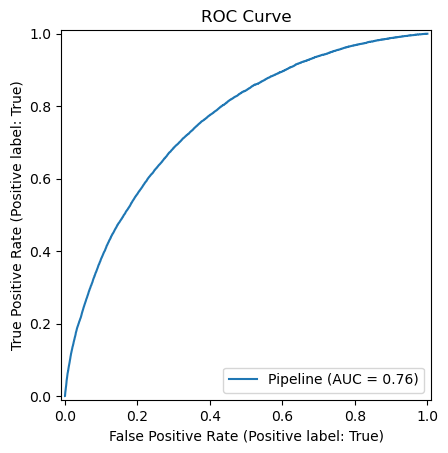

In [7]:
RocCurveDisplay.from_estimator(gs_logit_pipeline, X_train, y_train)
plt.title('ROC Curve')
plt.show()

Training performance:
    Accuracy  Recall  Precision     F1
0    0.6989  0.6850     0.1671 0.2687


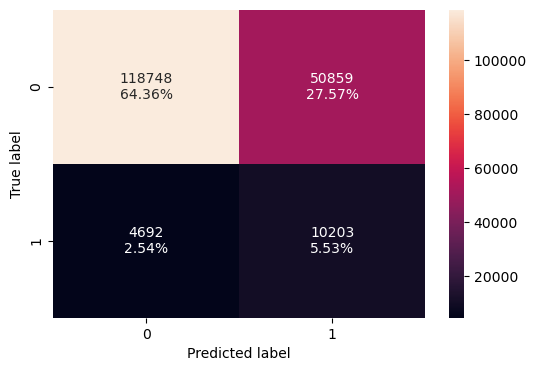

In [8]:
# checking model performance for AUC-ROC threshold
logit_model_train_perf = model_performance_classification_sklearn(
    gs_logit_pipeline, X_train, y_train
)
print("Training performance:\n",logit_model_train_perf)

# create confusion matrix
confusion_matrix_sklearn(gs_logit_pipeline, X_train, y_train)

### Find threshold

#### ROC-AUC

In [9]:
y_prob_lg = gs_logit_pipeline.predict_proba(X_train)[:, 1]

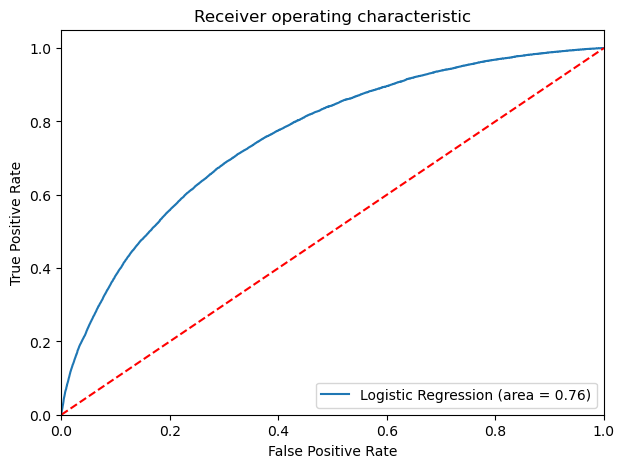

In [10]:
logit_roc_auc_train = roc_auc_score(y_train,y_prob_lg)
fpr, tpr, thresholds = roc_curve(y_train, y_prob_lg)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [11]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, y_prob_lg)

optimal_idx = np.argmax(tpr - fpr)
lg_optimal_threshold_auc_roc = round(thresholds[optimal_idx],2)
print(lg_optimal_threshold_auc_roc)

0.48


#### Precision-Recall curve

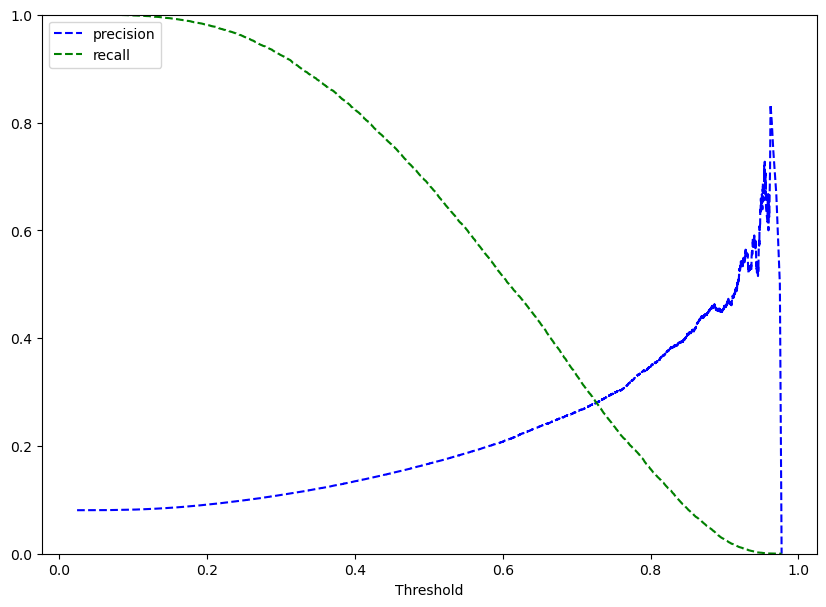

In [12]:
prec, rec, tre = precision_recall_curve(y_train, y_prob_lg)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [13]:
recall_slice = rec[(0.2 < rec) & (rec < 0.3)].tolist()
precision_slice = prec[(0.2 < prec) & (prec < 0.3)].tolist()

In [14]:
# searching the intersection point of recall and precision
print(intersection(recall_slice,precision_slice))
intersected = intersection(recall_slice,precision_slice)

[0.27982544478012755, 0.27982544478012755, 0.27982544478012755, 0.27982544478012755, 0.26686807653575023, 0.26686807653575023, 0.26666666666666666, 0.25579053373615307, 0.25579053373615307, 0.25579053373615307, 0.24605572339711312, 0.24605572339711312, 0.24605572339711312, 0.24605572339711312, 0.24605572339711312, 0.24444444444444444, 0.24444444444444444, 0.24444444444444444, 0.24169184290030213]


In [15]:
# extract the threshold 
intersect = pd.DataFrame({'prec': prec[:-1],
                          'rec': rec[:-1],
                          'tre': tre})

intersect[intersect['prec'] == 0.24605572339711312]

,prec,rec,tre
160670,0.2461,0.3937,0.6682


In [16]:
# setting the threshold
lg_optimal_threshold_curve = 0.67

### Performance result

#### ROC-AUC

Validation performance:
    Accuracy  Recall  Precision     F1
0    0.6696  0.7015     0.1560 0.2553


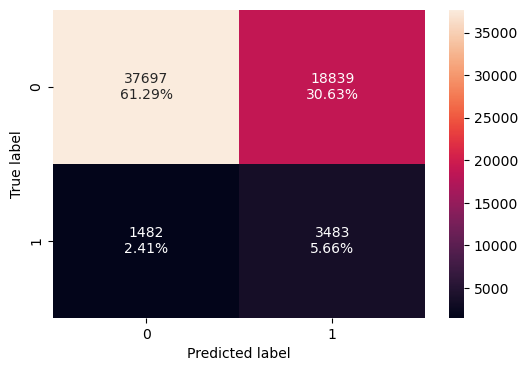

In [17]:
# checking model performance for AUC-ROC threshold
logit_model_val_perf_threshold_auc_roc = model_performance_classification_sklearn(
    gs_logit_pipeline, X_val, y_val, lg_optimal_threshold_auc_roc
)
print("Validation performance:\n",logit_model_val_perf_threshold_auc_roc)

# create confusion matrix
confusion_matrix_sklearn(gs_logit_pipeline, X_val, y_val, lg_optimal_threshold_auc_roc)

In [18]:
y_pred_proba_val = gs_logit_pipeline.predict_proba(X_val)[:,1]
y_pred = (y_pred_proba_val >= 0.5).astype(int)

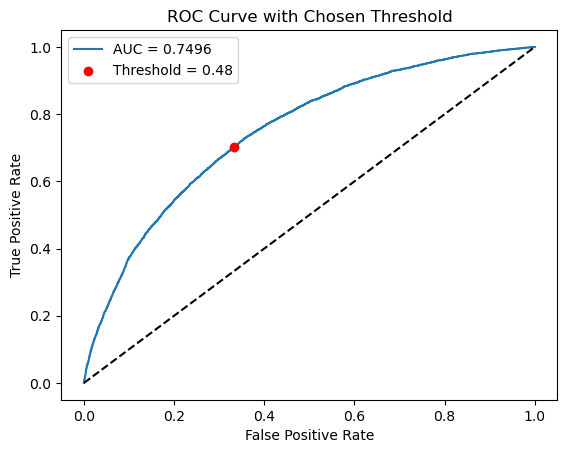

In [19]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_val)
auc = roc_auc_score(y_val, y_pred_proba_val)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')

# Mark your chosen threshold
idx = np.argmin(np.abs(thresholds - lg_optimal_threshold_auc_roc))
plt.scatter(fpr[idx], tpr[idx], color='red', zorder=5, 
            label=f'Threshold = {lg_optimal_threshold_auc_roc}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Chosen Threshold')
plt.legend()
plt.show()

#### PR-curve

Validation performance:
    Accuracy  Recall  Precision     F1
0    0.8531  0.3843     0.2419 0.2969


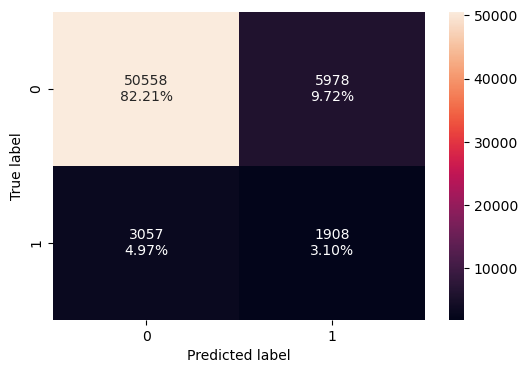

In [20]:
# checking model performance for AUC-ROC threshold
logit_model_val_perf_threshold_curve = model_performance_classification_sklearn(
    gs_logit_pipeline, X_val, y_val, lg_optimal_threshold_curve
)
print("Validation performance:\n",logit_model_val_perf_threshold_curve)

# create confusion matrix
confusion_matrix_sklearn(gs_logit_pipeline, X_val, y_val, lg_optimal_threshold_curve)

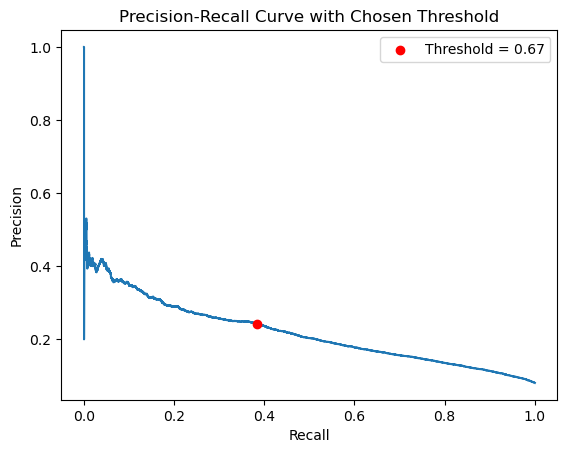

In [21]:
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_pred_proba_val)

plt.plot(recall, precision)

# Mark threshold
idx = np.argmin(np.abs(thresholds_pr - lg_optimal_threshold_curve))
plt.scatter(recall[idx], precision[idx], color='red', zorder=5,
            label=f'Threshold = {lg_optimal_threshold_curve}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Chosen Threshold')
plt.legend()
plt.show()

### More plots

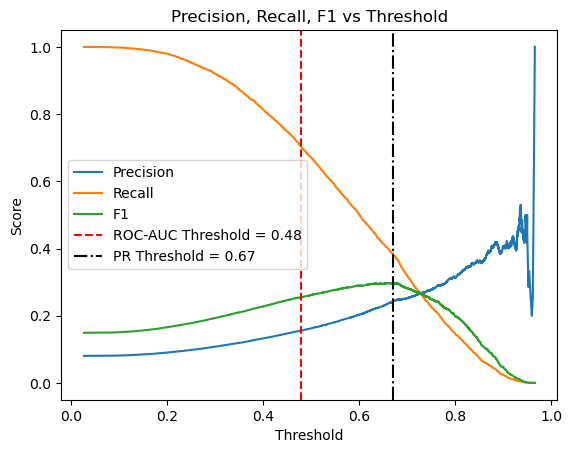

In [22]:
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_pred_proba_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')
plt.plot(thresholds_pr, f1[:-1], label='F1')
plt.axvline(x=lg_optimal_threshold_auc_roc, color='red', linestyle='--', 
            label=f'ROC-AUC Threshold = {lg_optimal_threshold_auc_roc}')
plt.axvline(x=lg_optimal_threshold_curve, color='black', linestyle='-.', 
            label=f'PR Threshold = {lg_optimal_threshold_curve}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.legend()
plt.show()

## XGBoost

In [23]:
gs_xgb_pipeline = joblib.load('xgb_pipeline.pkl')

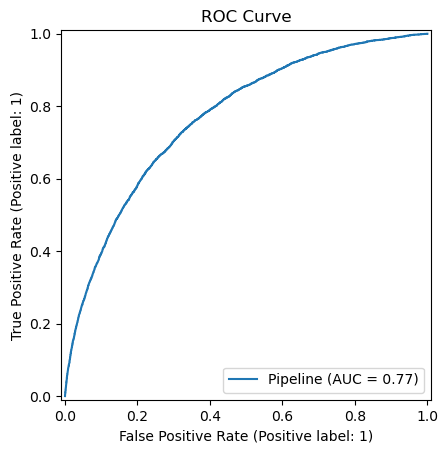

In [24]:
RocCurveDisplay.from_estimator(gs_xgb_pipeline, X_val, y_val)
plt.title('ROC Curve')
plt.show()

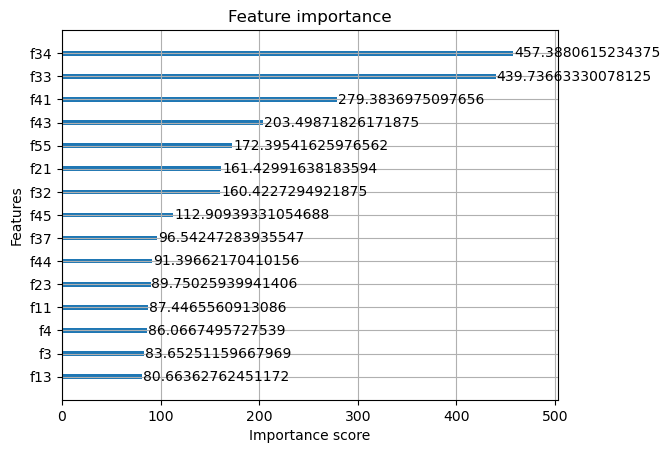

In [25]:
best_model = gs_xgb_pipeline.named_steps['gridsearchcv'].best_estimator_
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.show()

Validation performance:
    Accuracy  Recall  Precision     F1
0    0.7163  0.6808     0.1756 0.2792


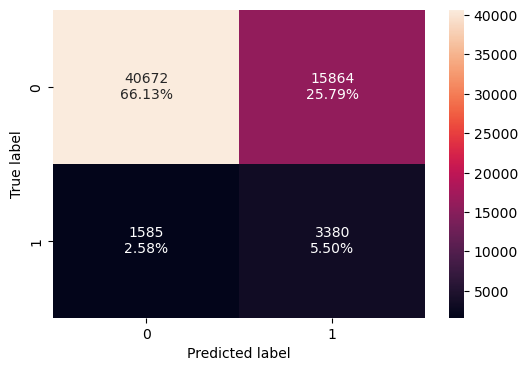

In [26]:
# checking model performance for AUC-ROC threshold
xgb_model_val_perf = model_performance_classification_sklearn(
    gs_xgb_pipeline, X_val, y_val
)
print("Validation performance:\n",xgb_model_val_perf)

# create confusion matrix
confusion_matrix_sklearn(gs_xgb_pipeline, X_val, y_val)

## SHAP

In [27]:
# Extract best model from pipeline
best_model = gs_xgb_pipeline.named_steps['gridsearchcv'].best_estimator_

In [28]:
X_val_sample = X_val.sample(1000, random_state=42)

# Get transformed X_val (pipeline preprocesses it first)
X_val_transformed = gs_xgb_pipeline.named_steps['columntransformer'].transform(X_val_sample)

In [57]:
feature_names = gs_xgb_pipeline.named_steps['columntransformer'].get_feature_names_out()

In [90]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_model,feature_names= feature_names)
shap_values = explainer(X_val_transformed)

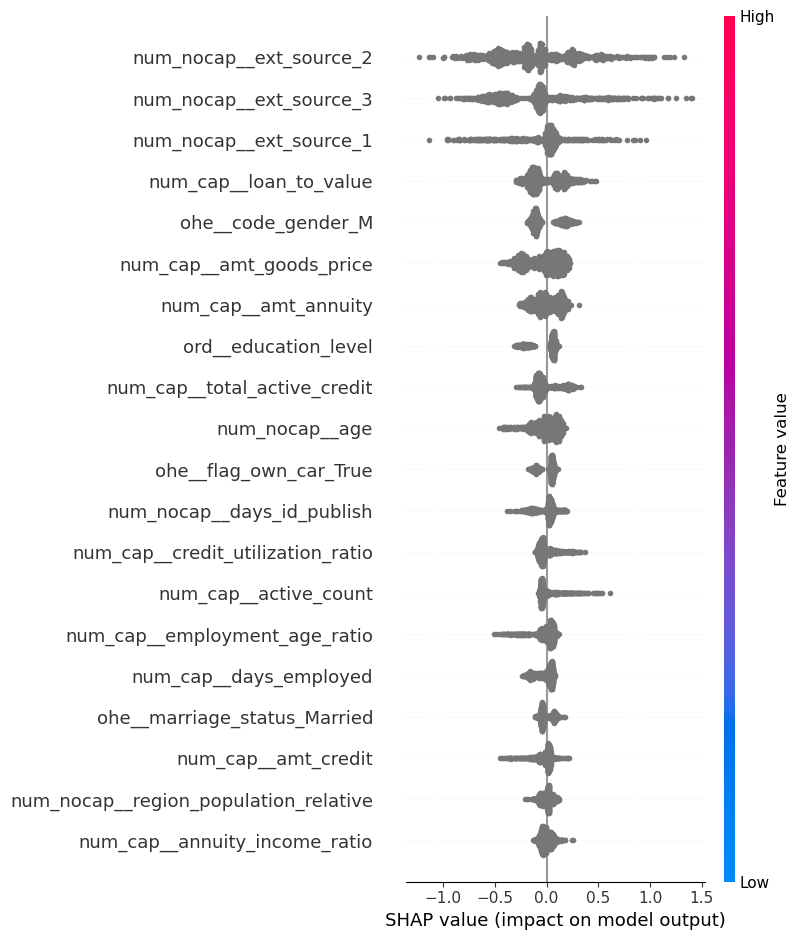

In [93]:
figsize=(15, 10)
shap.summary_plot(shap_values, X_val_transformed)

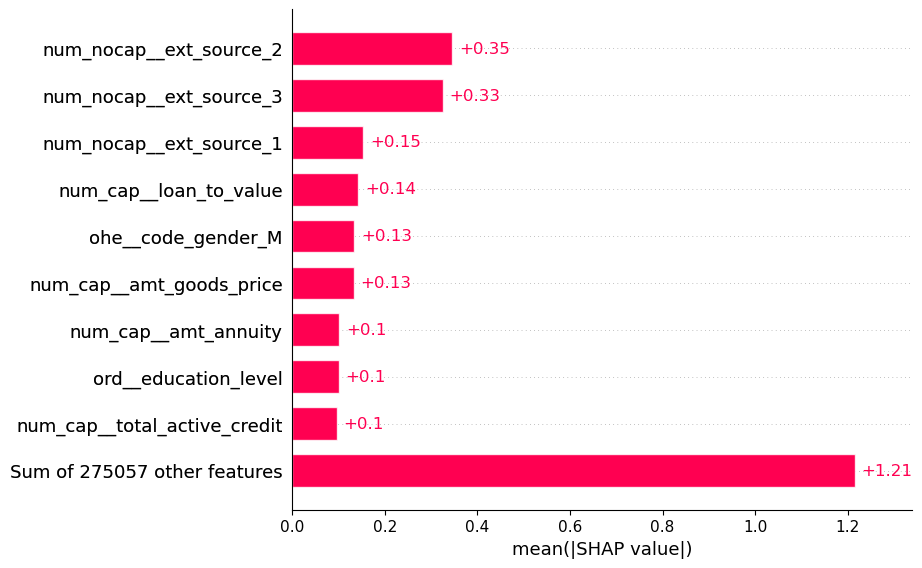

In [99]:
figsize=(30, 30)

shap.plots.bar(shap_values)

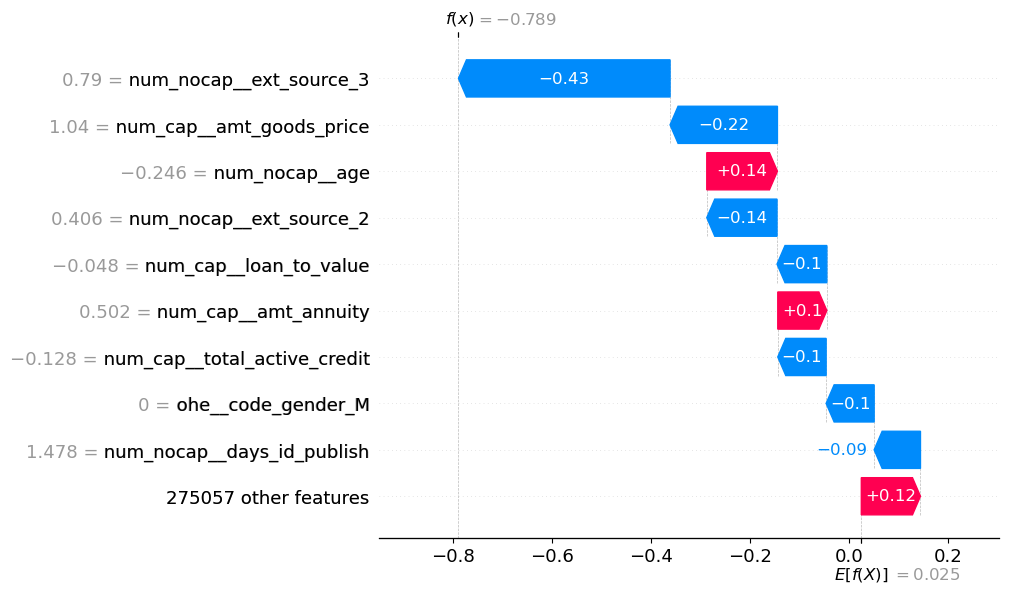

In [71]:
figsize=(15, 10)

shap.plots.waterfall(explainer(X_val_transformed)[0])

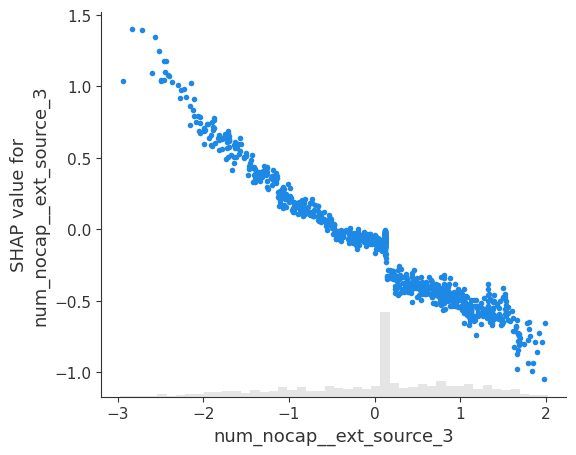

In [96]:
figsize=(15, 10)

shap.plots.scatter(shap_values[:,"num_nocap__ext_source_3"])